In [1]:
import pandas as pd
import numpy as np
import re
import plotly.express as px
from thefuzz import process, fuzz
%autosave 60

Autosaving every 60 seconds


In [2]:
df = pd.read_csv("../../../datasets/processed/mergedDF.csv")

In [3]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35104 entries, 0 to 35103
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   appid    35104 non-null  int64
 1   name     35104 non-null  str  
 2   min_req  35103 non-null  str  
 3   rec_req  21324 non-null  str  
dtypes: int64(1), str(3)
memory usage: 17.5 MB


In [5]:
df.head()

,appid,name,min_req,rec_req
0,379720,DOOM,"Minimum:,OS:,Windows 7/8.1/10 (64-bit versions...","Recommended:,OS:,Windows 7/8.1/10 (64-bit vers..."
1,578080,PLAYERUNKNOWN'S BATTLEGROUNDS,"Minimum:,Requires a 64-bit processor and opera...","Recommended:,Requires a 64-bit processor and o..."
2,637090,BATTLETECH,"Minimum:,Requires a 64-bit processor and opera...","Recommended:,Requires a 64-bit processor and o..."
3,221100,DayZ,"Minimum:,OS:,Windows 7/8.1 64-bit,Processor:,I...","Recommended:,OS:,Windows 10 64-bit,Processor:,..."
4,8500,EVE Online,"Minimum:,OS:,Windows 7,Processor:,Intel Dual C...","Recommended:,OS:,Windows 10,Processor:,Intel i..."


In [6]:
def extract_cpu(text):
    """Extract CPU info from Processor line."""
    CPU_LINE_PATTERN = r'(?i)(?:Processor|CPU):[,\s]+([^,]+)'
    if pd.isna(text):
        return None
    text = str(text)
    match = re.search(CPU_LINE_PATTERN, text)
    if match:
        return match.group(1).strip()
    return None

In [28]:
def extract_gpu(text):
    if pd.isna(text):
        return None
    idx = text.find('Graphics')
    if idx == -1:
        idx = text.find('Video')
        offset = 6 # "Video:" (6 chars offset)
        if idx == -1:
            return None
    else:
        offset = 9 # "Graphics:" (9 chars offset)
    comma = 0
    txt = ''
    for c in text[idx:]:
        if c == ',':
            comma+=1
            if text[idx:].index(c) != offset:
                break
        if comma == 2:
            break
        txt += c
    if "RAM" in txt[offset+1:]:
        return None
    return txt[offset+1:]

In [29]:
def clean_mac_req(text):
    if pd.isna(text):
        return None
    tmp = text
    min_count = 0
    for i, idx in zip(tmp.split(','), range(len(tmp.split(',')))):
        if 'Minimum:' in i:
            min_count+=1
        if min_count > 1:
            return ','.join(tmp.split(',')[:idx])
    return text

In [30]:
df['min_req'] = df['min_req'].apply(lambda x: clean_mac_req(x))

In [31]:
df['min_gpu'] = df['min_req'].apply(lambda x: extract_gpu(x))

In [32]:
df['min_cpu'] = df['min_req'].apply(lambda x: extract_cpu(x))

In [35]:
df.isna().sum()

appid          0
name           0
min_req        1
rec_req    13780
min_gpu     7488
min_cpu     2607
dtype: int64

---

In [37]:
benchdf = pd.read_csv("../../../datasets/raw/CPU_UserBenchmarks.csv")

In [38]:
df.head()

,appid,name,min_req,rec_req,min_gpu,min_cpu
0,379720,DOOM,"Minimum:,OS:,Windows 7/8.1/10 (64-bit versions...","Recommended:,OS:,Windows 7/8.1/10 (64-bit vers...",NVIDIA GTX 670 2GB/AMD Radeon HD 7870 2GB or b...,Intel Core i5-2400/AMD FX-8320 or better
1,578080,PLAYERUNKNOWN'S BATTLEGROUNDS,"Minimum:,Requires a 64-bit processor and opera...","Recommended:,Requires a 64-bit processor and o...",NVIDIA GeForce GTX 960 2GB / AMD Radeon R7 370...,Intel Core i5-4430 / AMD FX-6300
2,637090,BATTLETECH,"Minimum:,Requires a 64-bit processor and opera...","Recommended:,Requires a 64-bit processor and o...",NaN,Intel® Core™ i3-2105 or AMD® Phenom™ II X3 720
3,221100,DayZ,"Minimum:,OS:,Windows 7/8.1 64-bit,Processor:,I...","Recommended:,OS:,Windows 10 64-bit,Processor:,...",NVIDIA GeForce GTX 760 or AMD R9 270X,Intel Core i5-4430
4,8500,EVE Online,"Minimum:,OS:,Windows 7,Processor:,Intel Dual C...","Recommended:,OS:,Windows 10,Processor:,Intel i...",AMD Radeon 2600 XT or NVIDIA GeForce 8600 GTS,Intel Dual Core @ 2.0 GHz


In [39]:
benchdf.head()

,Type,Part Number,Brand,Model,Rank,Benchmark,Samples,URL
0,CPU,BX8071514900KS,Intel,Core i9-14900KS,1,133.0,1592,https://cpu.userbenchmark.com/SpeedTest/229530...
1,CPU,BX8071514900KF,Intel,Core i9-14900KF,2,131.0,7773,https://cpu.userbenchmark.com/SpeedTest/221221...
2,CPU,BX8071514900K,Intel,Core i9-14900K,3,131.0,19876,https://cpu.userbenchmark.com/Intel-Core-i9-14...
3,CPU,BX8071513900KS,Intel,Core i9-13900KS,4,131.0,4204,https://cpu.userbenchmark.com/SpeedTest/200081...
4,CPU,BX8071514700KF,Intel,Core i7-14700KF,5,130.0,4842,https://cpu.userbenchmark.com/SpeedTest/221202...


In [62]:
benchdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 1423 entries, 0 to 1422
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Brand      1423 non-null   str    
 1   Model      1423 non-null   str    
 2   Benchmark  1423 non-null   float64
dtypes: float64(1), str(2)
memory usage: 59.1 KB


In [60]:
benchdf = benchdf[['Brand', 'Model', 'Benchmark']]

In [76]:
benchdf.drop(benchdf[benchdf['Brand'].str.contains('Snapdragon')].index, inplace=True)

In [66]:
benchdf.drop(benchdf[benchdf['Model'].str.contains('APU')].index, inplace=True)

In [70]:
df['min_cpu'].values

<ArrowStringArray>
[                                                                  'Intel Core i5-2400/AMD FX-8320 or better',
                                                                           'Intel Core i5-4430 / AMD FX-6300',
                                                             'Intel® Core™ i3-2105 or AMD® Phenom™ II X3 720',
                                                                                         'Intel Core i5-4430',
                                                                                  'Intel Dual Core @ 2.0 GHz',
                                                                                       'Intel® Core™ i5-4460',
 'Intel Core2 Duo E6750 (2 * 2660) or equivalent | AMD Athlon 64 X2 Dual Core 6000+ (2 * 3000) or equivalent',
                                                                                                      'INTEL',
                                                                        'Intel® Core i3 or AM

In [300]:
cpu_bench = dict(zip(benchdf['Brand'] + " " + benchdf['Model'], benchdf['Benchmark']))
cpu_bench['Intel Core i7 4700'] = cpu_bench['Intel Core i7-4700MQ']
cpu_bench['Intel Core i5-3400'] = cpu_bench['Intel Core i5-3427U']
cpu_bench

{'Intel Core i9-14900KS': 133.0,
 'Intel Core i9-14900KF': 131.0,
 'Intel Core i9-14900K': 131.0,
 'Intel Core i9-13900KS': 131.0,
 'Intel Core i7-14700KF': 130.0,
 'Intel Core i7-14700K': 130.0,
 'Intel Core i9-13900KF': 129.0,
 'Intel Core i9-13900K': 129.0,
 'AMD Ryzen 7 9800X3D': 128.0,
 'Intel Core i7-13700KF': 126.0,
 'Intel Core i7-13700K': 126.0,
 'Intel Core i9-14900': 124.0,
 'Intel Core i9-14900F': 124.0,
 'Intel Core i5-14600KF': 124.0,
 'Intel Core i9-13900F': 124.0,
 'Intel Core i5-14600K': 124.0,
 'Intel Core i9-13900': 123.0,
 'Intel Core i5-13600K': 122.0,
 'Intel Core i5-13600KF': 122.0,
 'Intel Core Ultra 9 285K': 121.0,
 'Intel Core i7-14700F': 121.0,
 'Intel Core i7-14700': 121.0,
 'AMD Ryzen 7 7800X3D': 121.0,
 'Intel Core i7-13700F': 121.0,
 'Intel Core i7-13700': 121.0,
 'AMD Ryzen 9 9950X3D': 120.0,
 'Intel Core i9-12900KS': 119.0,
 'Intel Core Ultra 7 265KF': 119.0,
 'AMD Ryzen 9 9900X3D': 119.0,
 'Intel Core Ultra 7 265K': 119.0,
 'AMD Ryzen 9 9950X': 118.0,


In [121]:
def clean_cpu_string(text):
    if pd.isna(text):
        return
    # 1. Remove símbolos de marca registrada e caracteres especiais
    text = re.sub(r'[®™©@]', '', text)
    # Remove frequencies (e.g., 2.66 GHz, 3.2GHz, @ 2.0 GHz)
    text = re.sub(r'(?i)@?\s*\d+\.?\d*\s*[gm]hz', '', text)
    # Remove core counts in parentheses (e.g., (2 * 2660))
    text = re.sub(r'\(\d+\s*\*\s*\d+\)', '', text)
    # Replace 3rd and 4th by 3000 4000
    text = re.sub(r'(?i)3rd', '3000', text)
    text = re.sub(r'(?i)4rd', '4000', text)
    # 2. Remove ruídos comuns que confundem o fuzzy match
    noise = [
        'or better', 'or equivalent', 'or higher processor', 
        'equivalent', 'processor', 'generation'
    ]
    for word in noise:
        text = re.compile(re.escape(word), re.IGNORECASE).sub('', text)
    
    # 3. Remove especificações de núcleos/clock entre parênteses ex: (2 * 2660)
    text = re.sub(r'\(.*?\)', '', text)
    
    return text.strip()

In [ ]:
def bench_gpu_score(text):
    if pd.isna(text):
        return None

In [89]:
for i in df['min_cpu']:
    if pd.isna(i):
         continue
    print(i.split('/')[0])

Intel Core i5-2400
Intel Core i5-4430 
Intel® Core™ i3-2105 or AMD® Phenom™ II X3 720
Intel Core i5-4430
Intel Dual Core @ 2.0 GHz
Intel® Core™ i5-4460
Intel Core2 Duo E6750 (2 * 2660) or equivalent | AMD Athlon 64 X2 Dual Core 6000+ (2 * 3000) or equivalent
INTEL
Intel® Core i3 or AMD Phenom™ II X3
Intel Core2 Duo E4300 (2 * 1800) 
Intel Core i3-4170 @ 3.70GHz
Intel i3 2130 
Intel Core i3-3225 @ 3.30GHz or equivalent
Intel or AMD Dual-Core
Modern quad-core (AMD FX-Series or newer
Intel Core i5-3470 or AMD FX-8120
2.5 GHz
Intel Core i3 or Equivalent
Intel® Core™2 Duo E6600 or AMD Phenom™ X3 8750 or better
Intel® Core™ i3-4160
Intel Core i3 4130T (2.9GHz) 
2.0 GHz CPU
Intel Core 2 Duo 1.8GHz
2.4GHz Dual core CPU
Intel Core i3 3rd gen or equivalent
Intel Core i5-4460 
Intel i3
Intel i5 3570K 
2.8 GHz Intel Core 2 Duo or better
Intel Core i5-3470 | AMD FX-6300
Intel Core Duo E6600 @ 2.4GHz
Intel Pentium 4 1.5 GHz or Athlon XP 1500+
2GHz
Intel Core i3-2100 (3.1GHz) or AMD Phenom X4 945 (3.

In [122]:
df['min_cpu'] = df['min_cpu'].apply(lambda x: clean_cpu_string(x))

In [308]:
def cpu_match(text, score_dict):
    if pd.isna(text):
        return np.nan
    
    # --- B. SPLITTING ---
    # Split by "or", "|", or "/" to separate Intel and AMD mentions
    parts = re.split(r'(?i)\b or \b|\||/', text)
    
    matched_cpus = []
    
    # --- C. FUZZY MATCHING ---
    for part in parts:
        clean_part = part.strip(' ()') # clean trailing spaces and brackets
        if not clean_part or not any(char.isalnum() for char in clean_part):
            continue
        if len(clean_part) < 3 or not re.search(r'\d{3,}', clean_part): 
            continue # Skip empty or tiny strings like "i3" without brand or missing model like "Intel Core i3"
            
        # Extract the best match from our dictionary keys
        best_match, match_accuracy = process.extractOne(clean_part, score_dict.keys())
        
        # Only accept the match if it's confident enough (e.g., 80% similarity)
        if match_accuracy > 90:
            matched_cpus.append({
                "raw_string": part.strip(),
                "matched_model": best_match,
                "score": score_dict[best_match],
                "confidence": match_accuracy
            })
    if matched_cpus:
        return min(matched_cpus, key=lambda x: x['score'])['score']
    else:
        return cpu_match_generics(text)

In [316]:
def cpu_match_generics(text):
    if not text or not any(char.isalnum() for char in text):
        return None
    generics_score = {
        'i3': 36.1,
        'Intel Dual Core': 43.7,
        'Intel or AMD Dual-Core': 30.9,
        'Intel Core i3': 36.1,
        'Duo Core': 30.9,
        'Dual Core': 30.9,
        'Intel Core i5': 39.4,
        'Core i5': 39.4,
        'Intel i5': 39.4,
        'P4': 23,
        'Pentium 4': 23,
        'Pentium IV': 23,
        'i3 8100': 70.6
    }
    match, confidence = process.extractOne(text, generics_score.keys())
    if confidence > 80:
        return generics_score[match]
    return None

In [301]:
# Testing
# 3. Apply the function to the data
frame = df.loc[df['cpu_bench'] > 80, ['min_cpu']].reset_index(drop=True)
results = [cpu_match(row, cpu_bench) for row in frame['min_cpu']]
# Print results
for i, res in enumerate(results):
    print(f"Raw Row {i}: {frame['min_cpu'][i]}")
    print(f"Matches: {res}\n")

Raw Row 0: Intel Core i3-8350K
Matches: {'raw_string': 'Intel Core i3-8350K', 'matched_model': 'Intel Core i3-8350K', 'score': 81.7, 'confidence': 100}

Raw Row 1: Intel Core i7 4700 or higher
Matches: {'raw_string': 'Intel Core i7 4700', 'matched_model': 'Intel Core i7 4700', 'score': 58.6, 'confidence': 100}

Raw Row 2: Intel Core i5-8400
Matches: {'raw_string': 'Intel Core i5-8400', 'matched_model': 'Intel Core i5-8400', 'score': 81.8, 'confidence': 100}

Raw Row 3: Intel Core i3-8350K
Matches: {'raw_string': 'Intel Core i3-8350K', 'matched_model': 'Intel Core i3-8350K', 'score': 81.7, 'confidence': 100}

Raw Row 4: Intel Core i7 4700 or higher
Matches: {'raw_string': 'Intel Core i7 4700', 'matched_model': 'Intel Core i7 4700', 'score': 58.6, 'confidence': 100}

Raw Row 5: Intel Core i3-8350K
Matches: {'raw_string': 'Intel Core i3-8350K', 'matched_model': 'Intel Core i3-8350K', 'score': 81.7, 'confidence': 100}

Raw Row 6: Intel Core i7 4700 or higher
Matches: {'raw_string': 'Intel 

In [318]:
df['cpu_bench'] = df['min_cpu'].apply(lambda x: cpu_match(x, cpu_bench))

In [249]:
df.drop(df[df['min_cpu'].isna()].index, inplace=True)
df.drop(df[df['cpu_bench'].isna()].index, inplace=True)

In [270]:
df = df.reset_index(drop=True)

In [340]:
df[df['cpu_bench'] > 85]

,appid,name,min_req,rec_req,min_gpu,min_cpu,cpu_bench
23816,1059220,'83,"Minimum: , Requires a 64-bit processor and ope...","Recommended: , Requires a 64-bit processor and...",RTX 1660 / RX 5500 XT,Intel Core i7-8700 / Ryzen 3600,87.0


In [321]:
df.isna().sum()

appid           0
name            0
min_req         0
rec_req      8161
min_gpu      3622
min_cpu         0
cpu_bench       0
dtype: int64

In [274]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24413 entries, 0 to 24412
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   appid      24413 non-null  int64  
 1   name       24413 non-null  str    
 2   min_req    24413 non-null  str    
 3   rec_req    16252 non-null  str    
 4   min_gpu    20791 non-null  str    
 5   min_cpu    24413 non-null  str    
 6   cpu_bench  24413 non-null  float64
dtypes: float64(1), int64(1), str(5)
memory usage: 13.8 MB


In [325]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, silhouette_samples

In [326]:
feature = df[['cpu_bench']]

In [329]:
#X = StandardScaler().fit_transform(feature)
X = feature
X

,cpu_bench
0,58.5
1,55.2
2,48.1
3,65.2
4,43.7
...,...
24408,39.8
24409,37.8
24410,37.8
24411,37.8


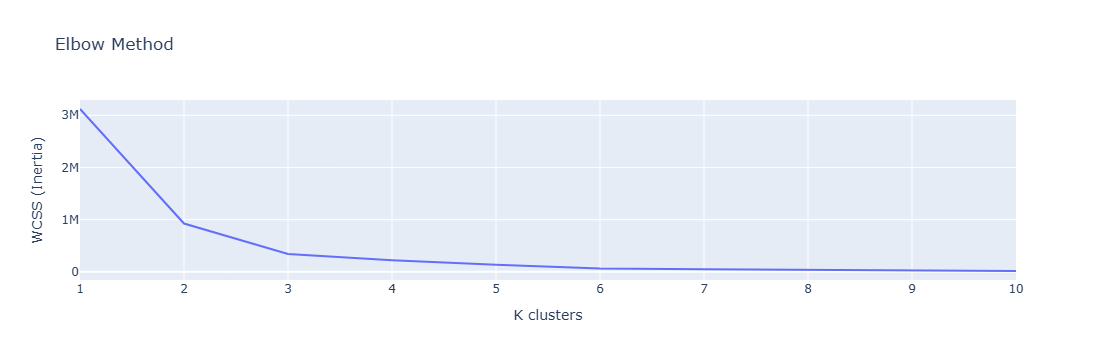

In [351]:
# Elbow Method
# Lista para armazenar os valores de inércia (WCSS)
wcss = []

# Testamos o K de 1 a 10
for i in range(1, 11):
    # n_init="auto" é o padrão para evitar avisos em versões novas
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init="auto")
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plotando o gráfico
pltdf = pd.DataFrame({'K clusters': range(1,11), 'WCSS (Inertia)': wcss})
px.line(pltdf, x='K clusters', y='WCSS (Inertia)', title='Elbow Method')

In [353]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto", init='k-means++').fit(X)

In [354]:
labels = kmeans.labels_
labels

array([0, 0, 2, ..., 2, 2, 2], shape=(24413,), dtype=int32)

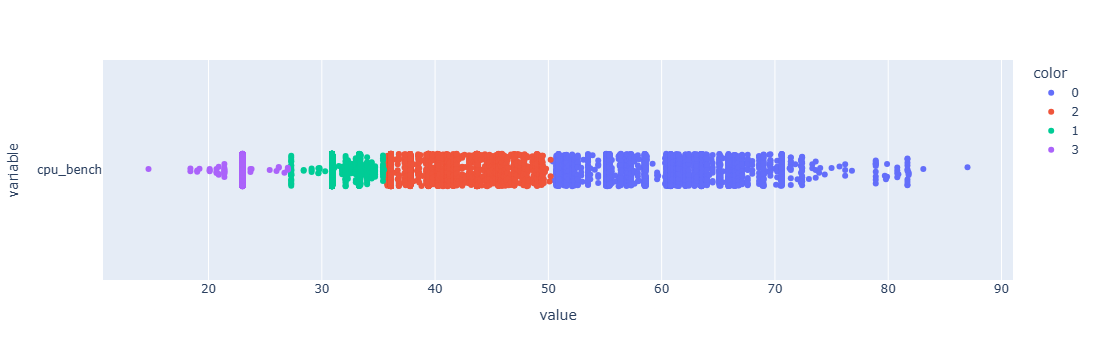

In [355]:
px.strip(X, color=labels, orientation='h', stripmode='overlay')

In [356]:
score_medio = silhouette_score(X, labels)
score_medio

0.7561227537207138